#Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import tensorflow as tf
import random
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras import regularizers
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set seaborn theme for  the plots
sns.set_theme(style="darkgrid")

In [3]:
# Import and mount Google Drive.
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
def load_datasets(file_paths):
    """
    Load multiple datasets into a dictionary of DataFrames.
    Returns:
        dict: Dictionary with keys as dataset names and values as loaded DataFrames.
    """
    datasets = {}
    for name, path in file_paths.items():
        try:
            datasets[name] = pd.read_csv(path, encoding='latin1')
            print({name})
        except Exception as e:
            print({name})

    return datasets

# Define file paths for datasets
file_paths = {
    "Global_temp": "/content/drive/MyDrive/Project/GLB.Ts+dSST.csv",
    "North_temp": "/content/drive/MyDrive/Project/NH.Ts+dSST.csv",
    "South_temp": "/content/drive/MyDrive/Project/SH.Ts+dSST.csv",
    "Zone_temp":"/content/drive/MyDrive/Project/ZonAnn.Ts+dSST.csv"
}

# Load datasets
datasets = load_datasets(file_paths)

# Access individual datasets by name
Global_temp = datasets["Global_temp"]
North_temp= datasets["North_temp"]
South_temp= datasets["South_temp"]
Zone_temp= datasets["Zone_temp"]


#Display the first few rows of each dataset
for name, data in datasets.items():
    print(f"\nDataset: {name}")
    print(data.head())


{'Global_temp'}
{'North_temp'}
{'South_temp'}
{'Zone_temp'}

Dataset: Global_temp
   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct    Nov  \
0  1880 -0.20 -0.26 -0.09 -0.17 -0.10 -0.22 -0.20 -0.11 -0.16 -0.23  -0.23   
1  1881 -0.20 -0.16  0.02  0.04  0.06 -0.19  0.01 -0.04 -0.16 -0.22  -0.19   
2  1882  0.16  0.13  0.04 -0.16 -0.14 -0.23 -0.16 -0.08 -0.15 -0.24  -0.17   
3  1883 -0.29 -0.37 -0.12 -0.18 -0.18 -0.07 -0.07 -0.14 -0.22 -0.12  -0.24   
4  1884 -0.13 -0.08 -0.36 -0.40 -0.34 -0.35 -0.31 -0.28 -0.27 -0.25  -0.34   

     Dec    J-D    D-N    DJF   MAM   JJA    SON  
0  -0.19  -0.18    ***    *** -0.12 -0.18  -0.21  
1  -0.08  -0.09   -0.1  -0.18  0.04 -0.08  -0.19  
2  -0.36  -0.11  -0.09   0.07 -0.09 -0.16  -0.19  
3  -0.11  -0.18   -0.2  -0.34 -0.16 -0.10  -0.19  
4  -0.31  -0.28  -0.27  -0.11 -0.37 -0.31  -0.28  

Dataset: North_temp
   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct    Nov  \
0  1880 -0.39 -0.54 -0.24 -0.31 -0.05 -0.18 

In [5]:
Global_temp

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.20,-0.26,-0.09,-0.17,-0.10,-0.22,-0.20,-0.11,-0.16,-0.23,-0.23,-0.19,-0.18,***,***,-0.12,-0.18,-0.21
1,1881,-0.20,-0.16,0.02,0.04,0.06,-0.19,0.01,-0.04,-0.16,-0.22,-0.19,-0.08,-0.09,-0.1,-0.18,0.04,-0.08,-0.19
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.16,-0.08,-0.15,-0.24,-0.17,-0.36,-0.11,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,-0.29,-0.37,-0.12,-0.18,-0.18,-0.07,-0.07,-0.14,-0.22,-0.12,-0.24,-0.11,-0.18,-0.2,-0.34,-0.16,-0.10,-0.19
4,1884,-0.13,-0.08,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.28,-0.27,-0.11,-0.37,-0.31,-0.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,2020,1.18,1.24,1.18,1.12,0.99,0.91,0.89,0.86,0.96,0.87,1.1,0.79,1.01,1.03,1.18,1.10,0.89,0.98
141,2021,0.81,0.65,0.89,0.76,0.79,0.84,0.92,0.81,0.92,0.99,0.93,0.88,0.85,0.84,0.75,0.81,0.86,0.95
142,2022,0.91,0.89,1.05,0.83,0.84,0.92,0.94,0.95,0.89,0.97,0.74,0.8,0.89,0.9,0.89,0.91,0.94,0.86
143,2023,0.88,0.98,1.23,0.99,0.94,1.08,1.19,1.19,1.48,1.34,1.42,1.36,1.17,1.13,0.89,1.06,1.16,1.41


In [6]:
North_temp


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.39,-0.54,-0.24,-0.31,-0.05,-0.18,-0.23,-0.27,-0.26,-0.31,-0.46,-0.43,-0.31,***,***,-0.20,-0.23,-0.34
1,1881,-0.31,-0.26,-0.07,-0.03,0.03,-0.34,0.08,-0.06,-0.29,-0.45,-0.38,-0.24,-0.19,-0.21,-0.33,-0.02,-0.11,-0.37
2,1882,0.25,0.20,0.01,-0.31,-0.24,-0.29,-0.28,-0.17,-0.26,-0.53,-0.34,-0.69,-0.22,-0.18,0.07,-0.18,-0.25,-0.38
3,1883,-0.58,-0.66,-0.15,-0.30,-0.26,-0.11,-0.06,-0.23,-0.34,-0.16,-0.45,-0.15,-0.29,-0.33,-0.64,-0.24,-0.13,-0.32
4,1884,-0.17,-0.11,-0.64,-0.59,-0.36,-0.41,-0.41,-0.51,-0.45,-0.45,-0.58,-0.47,-0.43,-0.4,-0.14,-0.53,-0.45,-0.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,2020,1.59,1.70,1.67,1.40,1.27,1.14,1.10,1.12,1.19,1.21,1.59,1.19,1.35,1.36,1.56,1.44,1.12,1.33
141,2021,1.25,0.96,1.21,1.13,1.05,1.21,1.07,1.03,1.05,1.30,1.29,1.17,1.14,1.14,1.13,1.13,1.10,1.21
142,2022,1.25,1.17,1.41,1.09,1.02,1.13,1.06,1.17,1.15,1.31,1.1,1.06,1.16,1.17,1.19,1.17,1.12,1.19
143,2023,1.30,1.30,1.64,1.02,1.13,1.19,1.45,1.57,1.67,1.88,1.98,1.85,1.5,1.43,1.22,1.26,1.40,1.84


In [7]:
South_temp

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.01,0.02,0.05,-0.03,-0.13,-0.25,-0.17,0.06,-0.05,-0.15,-0.01,0.05,-0.05,***,***,-0.04,-0.12,-0.07
1,1881,-0.09,-0.07,0.09,0.09,0.08,-0.06,-0.08,-0.03,-0.05,-0.01,-0.01,0.09,0,-0.01,-0.04,0.09,-0.05,-0.02
2,1882,0.06,0.06,0.07,-0.02,-0.05,-0.16,-0.05,0.01,-0.05,0.03,-0.02,-0.08,-0.02,0,0.07,0.00,-0.07,-0.01
3,1883,-0.03,-0.09,-0.09,-0.08,-0.10,-0.02,-0.08,-0.05,-0.11,-0.06,-0.05,-0.07,-0.07,-0.07,-0.07,-0.09,-0.05,-0.07
4,1884,-0.09,-0.06,-0.11,-0.22,-0.32,-0.29,-0.22,-0.07,-0.11,-0.07,-0.11,-0.16,-0.15,-0.14,-0.07,-0.22,-0.19,-0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,2020,0.76,0.78,0.68,0.84,0.72,0.69,0.68,0.61,0.74,0.53,0.61,0.4,0.67,0.71,0.79,0.75,0.66,0.63
141,2021,0.36,0.33,0.57,0.38,0.53,0.48,0.76,0.60,0.79,0.68,0.57,0.58,0.55,0.54,0.36,0.49,0.61,0.68
142,2022,0.58,0.61,0.67,0.58,0.66,0.71,0.81,0.72,0.62,0.61,0.38,0.53,0.62,0.63,0.59,0.63,0.74,0.54
143,2023,0.46,0.65,0.82,0.96,0.76,0.98,0.95,0.83,1.29,0.82,0.87,0.87,0.85,0.83,0.55,0.84,0.92,0.99


In [8]:
Zone_temp


,Year,Glob,NHem,SHem,24N-90N,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
0,1880,-0.18,-0.31,-0.05,-0.41,-0.13,-0.02,-0.82,-0.52,-0.32,-0.14,-0.11,-0.05,0.05,0.68
1,1881,-0.09,-0.19,0.00,-0.38,0.10,-0.07,-0.94,-0.49,-0.22,0.11,0.10,-0.06,-0.07,0.60
2,1882,-0.11,-0.22,-0.02,-0.33,-0.04,0.01,-1.43,-0.31,-0.16,-0.04,-0.05,0.00,0.04,0.63
3,1883,-0.18,-0.29,-0.07,-0.36,-0.16,-0.02,-0.18,-0.58,-0.27,-0.17,-0.16,-0.05,0.07,0.51
4,1884,-0.28,-0.43,-0.15,-0.62,-0.14,-0.14,-1.31,-0.67,-0.47,-0.11,-0.17,-0.20,-0.02,0.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2019,0.98,1.21,0.74,1.42,0.90,0.64,2.74,1.43,1.00,0.90,0.89,0.73,0.41,0.81
140,2020,1.01,1.35,0.67,1.67,0.85,0.56,2.87,1.81,1.19,0.88,0.82,0.58,0.39,0.87
141,2021,0.85,1.14,0.55,1.43,0.65,0.53,2.06,1.36,1.27,0.72,0.58,0.72,0.33,0.30
142,2022,0.89,1.16,0.62,1.52,0.56,0.70,2.35,1.50,1.27,0.62,0.51,0.78,0.40,1.08


In [9]:
columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
           'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']

df1 = pd.DataFrame(Global_temp, columns=columns)
df2 = pd.DataFrame(North_temp, columns=columns)
df3 = pd.DataFrame(South_temp, columns=columns)

# Concatenate datasets
Joined_data = pd.concat([df1, df2, df3], ignore_index=True)

Joined_data.replace('***', pd.NA, inplace=True)

# Display the concatenated dataset
Joined_data


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.20,-0.26,-0.09,-0.17,-0.10,-0.22,-0.20,-0.11,-0.16,-0.23,-0.23,-0.19,-0.18,<NA>,<NA>,-0.12,-0.18,-0.21
1,1881,-0.20,-0.16,0.02,0.04,0.06,-0.19,0.01,-0.04,-0.16,-0.22,-0.19,-0.08,-0.09,-0.1,-0.18,0.04,-0.08,-0.19
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.16,-0.08,-0.15,-0.24,-0.17,-0.36,-0.11,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,-0.29,-0.37,-0.12,-0.18,-0.18,-0.07,-0.07,-0.14,-0.22,-0.12,-0.24,-0.11,-0.18,-0.2,-0.34,-0.16,-0.10,-0.19
4,1884,-0.13,-0.08,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.28,-0.27,-0.11,-0.37,-0.31,-0.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,2020,0.76,0.78,0.68,0.84,0.72,0.69,0.68,0.61,0.74,0.53,0.61,0.4,0.67,0.71,0.79,0.75,0.66,0.63
431,2021,0.36,0.33,0.57,0.38,0.53,0.48,0.76,0.60,0.79,0.68,0.57,0.58,0.55,0.54,0.36,0.49,0.61,0.68
432,2022,0.58,0.61,0.67,0.58,0.66,0.71,0.81,0.72,0.62,0.61,0.38,0.53,0.62,0.63,0.59,0.63,0.74,0.54
433,2023,0.46,0.65,0.82,0.96,0.76,0.98,0.95,0.83,1.29,0.82,0.87,0.87,0.85,0.83,0.55,0.84,0.92,0.99


In [10]:
Joined_data=pd.merge(Joined_data, Zone_temp, on='Year')

In [11]:
Joined_data.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,...,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
0,1880,-0.20,-0.26,-0.09,-0.17,-0.10,-0.22,-0.20,-0.11,-0.16,...,-0.13,-0.02,-0.82,-0.52,-0.32,-0.14,-0.11,-0.05,0.05,0.68
1,1881,-0.20,-0.16,0.02,0.04,0.06,-0.19,0.01,-0.04,-0.16,...,0.10,-0.07,-0.94,-0.49,-0.22,0.11,0.10,-0.06,-0.07,0.60
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.16,-0.08,-0.15,...,-0.04,0.01,-1.43,-0.31,-0.16,-0.04,-0.05,0.00,0.04,0.63
3,1883,-0.29,-0.37,-0.12,-0.18,-0.18,-0.07,-0.07,-0.14,-0.22,...,-0.16,-0.02,-0.18,-0.58,-0.27,-0.17,-0.16,-0.05,0.07,0.51
4,1884,-0.13,-0.08,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,...,-0.14,-0.14,-1.31,-0.67,-0.47,-0.11,-0.17,-0.20,-0.02,0.66


In [12]:
Joined_data.tail()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,...,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
427,2019,0.66,0.78,0.78,0.77,0.71,0.62,0.84,0.79,0.64,...,0.90,0.64,2.74,1.43,1.00,0.90,0.89,0.73,0.41,0.81
428,2020,0.76,0.78,0.68,0.84,0.72,0.69,0.68,0.61,0.74,...,0.85,0.56,2.87,1.81,1.19,0.88,0.82,0.58,0.39,0.87
429,2021,0.36,0.33,0.57,0.38,0.53,0.48,0.76,0.60,0.79,...,0.65,0.53,2.06,1.36,1.27,0.72,0.58,0.72,0.33,0.30
430,2022,0.58,0.61,0.67,0.58,0.66,0.71,0.81,0.72,0.62,...,0.56,0.70,2.35,1.50,1.27,0.62,0.51,0.78,0.40,1.08
431,2023,0.46,0.65,0.82,0.96,0.76,0.98,0.95,0.83,1.29,...,1.06,0.71,2.58,1.87,1.47,1.08,1.05,0.90,0.45,0.62


In [13]:
Joined_data

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,...,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
0,1880,-0.20,-0.26,-0.09,-0.17,-0.10,-0.22,-0.20,-0.11,-0.16,...,-0.13,-0.02,-0.82,-0.52,-0.32,-0.14,-0.11,-0.05,0.05,0.68
1,1881,-0.20,-0.16,0.02,0.04,0.06,-0.19,0.01,-0.04,-0.16,...,0.10,-0.07,-0.94,-0.49,-0.22,0.11,0.10,-0.06,-0.07,0.60
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.16,-0.08,-0.15,...,-0.04,0.01,-1.43,-0.31,-0.16,-0.04,-0.05,0.00,0.04,0.63
3,1883,-0.29,-0.37,-0.12,-0.18,-0.18,-0.07,-0.07,-0.14,-0.22,...,-0.16,-0.02,-0.18,-0.58,-0.27,-0.17,-0.16,-0.05,0.07,0.51
4,1884,-0.13,-0.08,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,...,-0.14,-0.14,-1.31,-0.67,-0.47,-0.11,-0.17,-0.20,-0.02,0.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,2019,0.66,0.78,0.78,0.77,0.71,0.62,0.84,0.79,0.64,...,0.90,0.64,2.74,1.43,1.00,0.90,0.89,0.73,0.41,0.81
428,2020,0.76,0.78,0.68,0.84,0.72,0.69,0.68,0.61,0.74,...,0.85,0.56,2.87,1.81,1.19,0.88,0.82,0.58,0.39,0.87
429,2021,0.36,0.33,0.57,0.38,0.53,0.48,0.76,0.60,0.79,...,0.65,0.53,2.06,1.36,1.27,0.72,0.58,0.72,0.33,0.30
430,2022,0.58,0.61,0.67,0.58,0.66,0.71,0.81,0.72,0.62,...,0.56,0.70,2.35,1.50,1.27,0.62,0.51,0.78,0.40,1.08


#EDA

In [14]:
Joined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 33 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     432 non-null    int64  
 1   Jan      432 non-null    float64
 2   Feb      432 non-null    float64
 3   Mar      432 non-null    float64
 4   Apr      432 non-null    float64
 5   May      432 non-null    float64
 6   Jun      432 non-null    float64
 7   Jul      432 non-null    float64
 8   Aug      432 non-null    float64
 9   Sep      432 non-null    float64
 10  Oct      432 non-null    float64
 11  Nov      432 non-null    object 
 12  Dec      432 non-null    object 
 13  J-D      432 non-null    object 
 14  D-N      429 non-null    object 
 15  DJF      429 non-null    object 
 16  MAM      432 non-null    float64
 17  JJA      432 non-null    float64
 18  SON      432 non-null    object 
 19  Glob     432 non-null    float64
 20  NHem     432 non-null    float64
 21  SHem     432 non

In [15]:
# Summary statistics for the numerical columns
Joined_data.describe()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,...,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
count,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,...,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000
mean,1951.500000,0.063194,0.069537,0.087546,0.062384,0.053796,0.041366,0.065972,0.063611,0.068380,...,0.076181,0.002778,0.259306,0.140069,0.053958,0.068958,0.082639,0.045903,-0.051528,-0.067431
std,41.616412,0.450907,0.452678,0.454961,0.411175,0.387053,0.385898,0.366940,0.384468,0.389251,...,0.352951,0.313906,1.022914,0.606929,0.429233,0.354214,0.358331,0.333186,0.277382,0.759354
min,1880.000000,-1.490000,-0.940000,-0.810000,-0.650000,-0.730000,-0.670000,-0.590000,-0.770000,-0.800000,...,-0.630000,-0.480000,-1.770000,-0.800000,-0.620000,-0.670000,-0.590000,-0.440000,-0.540000,-2.590000
25%,1915.750000,-0.242500,-0.240000,-0.220000,-0.242500,-0.240000,-0.260000,-0.200000,-0.210000,-0.210000,...,-0.192500,-0.240000,-0.392500,-0.310000,-0.230000,-0.202500,-0.180000,-0.210000,-0.260000,-0.525000
50%,1951.500000,-0.020000,-0.030000,0.000000,-0.025000,-0.040000,-0.050000,-0.030000,-0.050000,-0.040000,...,0.000000,-0.075000,0.095000,-0.005000,-0.065000,0.010000,0.000000,-0.060000,-0.080000,0.065000
75%,1987.250000,0.340000,0.380000,0.340000,0.310000,0.262500,0.250000,0.262500,0.280000,0.280000,...,0.310000,0.262500,0.762500,0.447500,0.172500,0.280000,0.320000,0.290000,0.200000,0.480000
max,2023.000000,1.590000,1.930000,1.890000,1.460000,1.270000,1.210000,1.450000,1.570000,1.670000,...,1.060000,0.710000,3.250000,1.870000,1.470000,1.080000,1.060000,0.900000,0.450000,1.290000


In [16]:
#Checking for wrong entries like symbols -,?,#,*,etc.
for col in Joined_data.columns:
    print('{} : {}'.format(col,Joined_data[col].unique()))

Year : [1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891 1892 1893
 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905 1906 1907
 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919 1920 1921
 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933 1934 1935
 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947 1948 1949
 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023]
Jan : [-0.2   0.16 -0.29 -0.13 -0.58 -0.44 -0.72 -0.34 -0.09 -0.42 -0.33 -0.28
 -0.81 -0.52 -0.41 -0.22 -0.15 -0.03 -0.17 -0.36 -0.16 -0.24 -0.63 -0.35
 -0.43 -0.73 -0.62 -0.25 -0.4   0.04 -0.21 -0.57 -0.48 -0.05 -0.27 -0.37
  0.21 -0.02 -0.45 -0.3  -0.1  -0.23

In [17]:
for col in Joined_data.columns:
    Joined_data[col].replace({'?':np.nan},inplace=True)

In [18]:
# Check for missing values
missing_data = Joined_data.isnull().sum()
print(missing_data[missing_data > 0])

D-N    3
DJF    3
dtype: int64


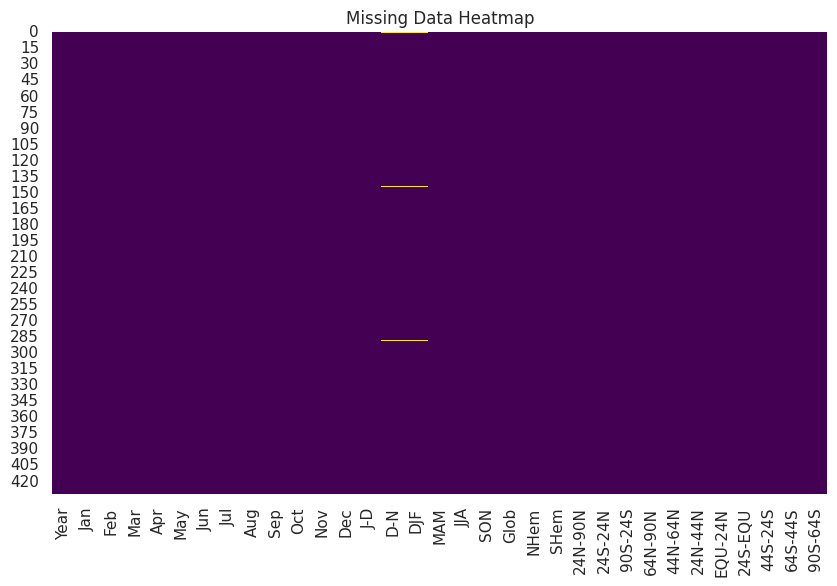

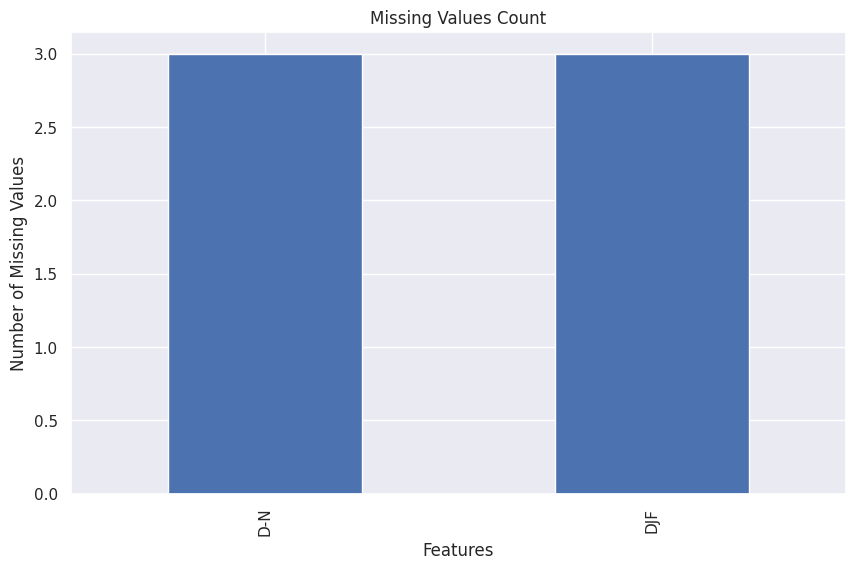

In [19]:
# Heatmap to show missing data
plt.figure(figsize=(10, 6))
sns.heatmap(Joined_data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# Bar plot of missing values
missing_values = Joined_data.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(inplace=True)
missing_values.plot(kind='bar', figsize=(10, 6))
plt.title("Missing Values Count")
plt.ylabel("Number of Missing Values")
plt.xlabel("Features")
plt.show()


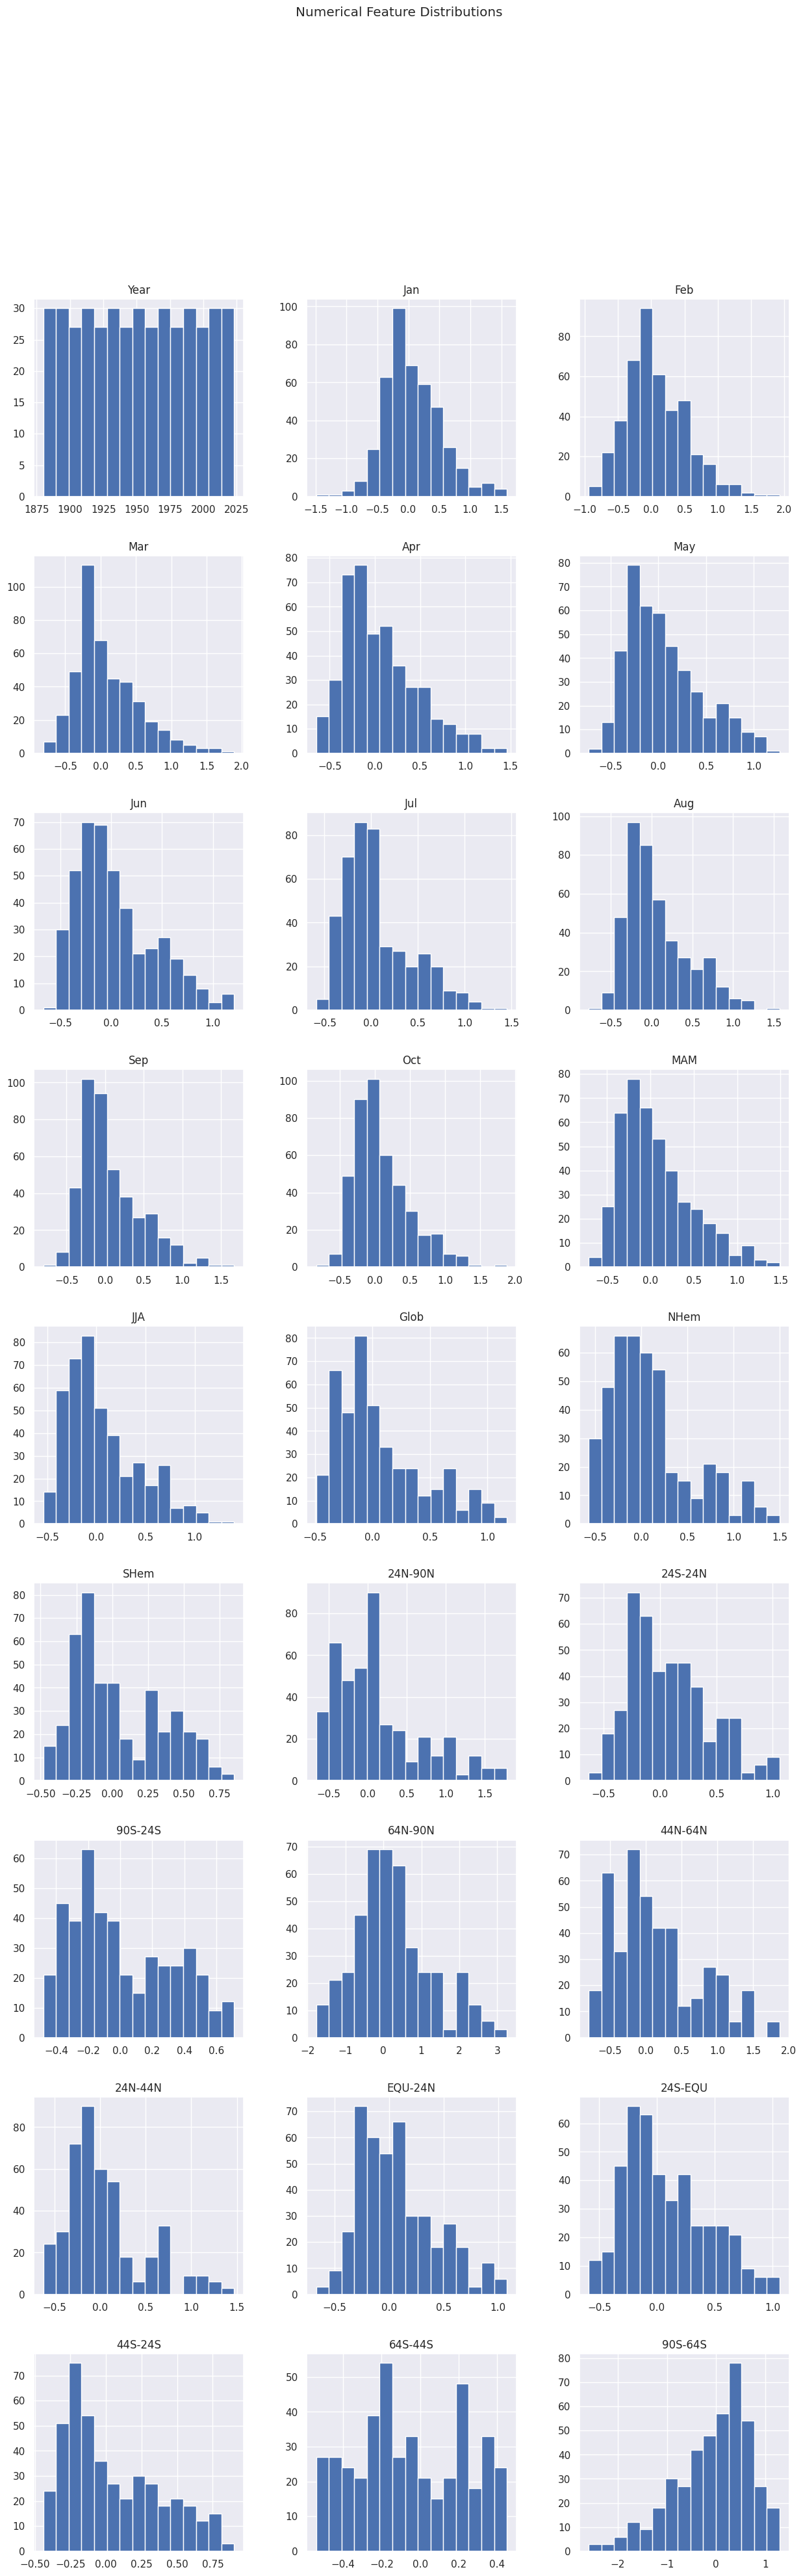

In [20]:
numerical_columns = Joined_data.select_dtypes(include=['float64', 'int64']).columns
# number of numerical columns
num_cols = len(numerical_columns)

# Calculate the required number of rows and columns for the grid
ncols = 3
nrows = math.ceil(num_cols / ncols)

# Plot the histograms
Joined_data[numerical_columns].hist(bins=15, figsize=(ncols * 5, nrows * 5), layout=(nrows, ncols))
plt.suptitle("Numerical Feature Distributions")
plt.show()


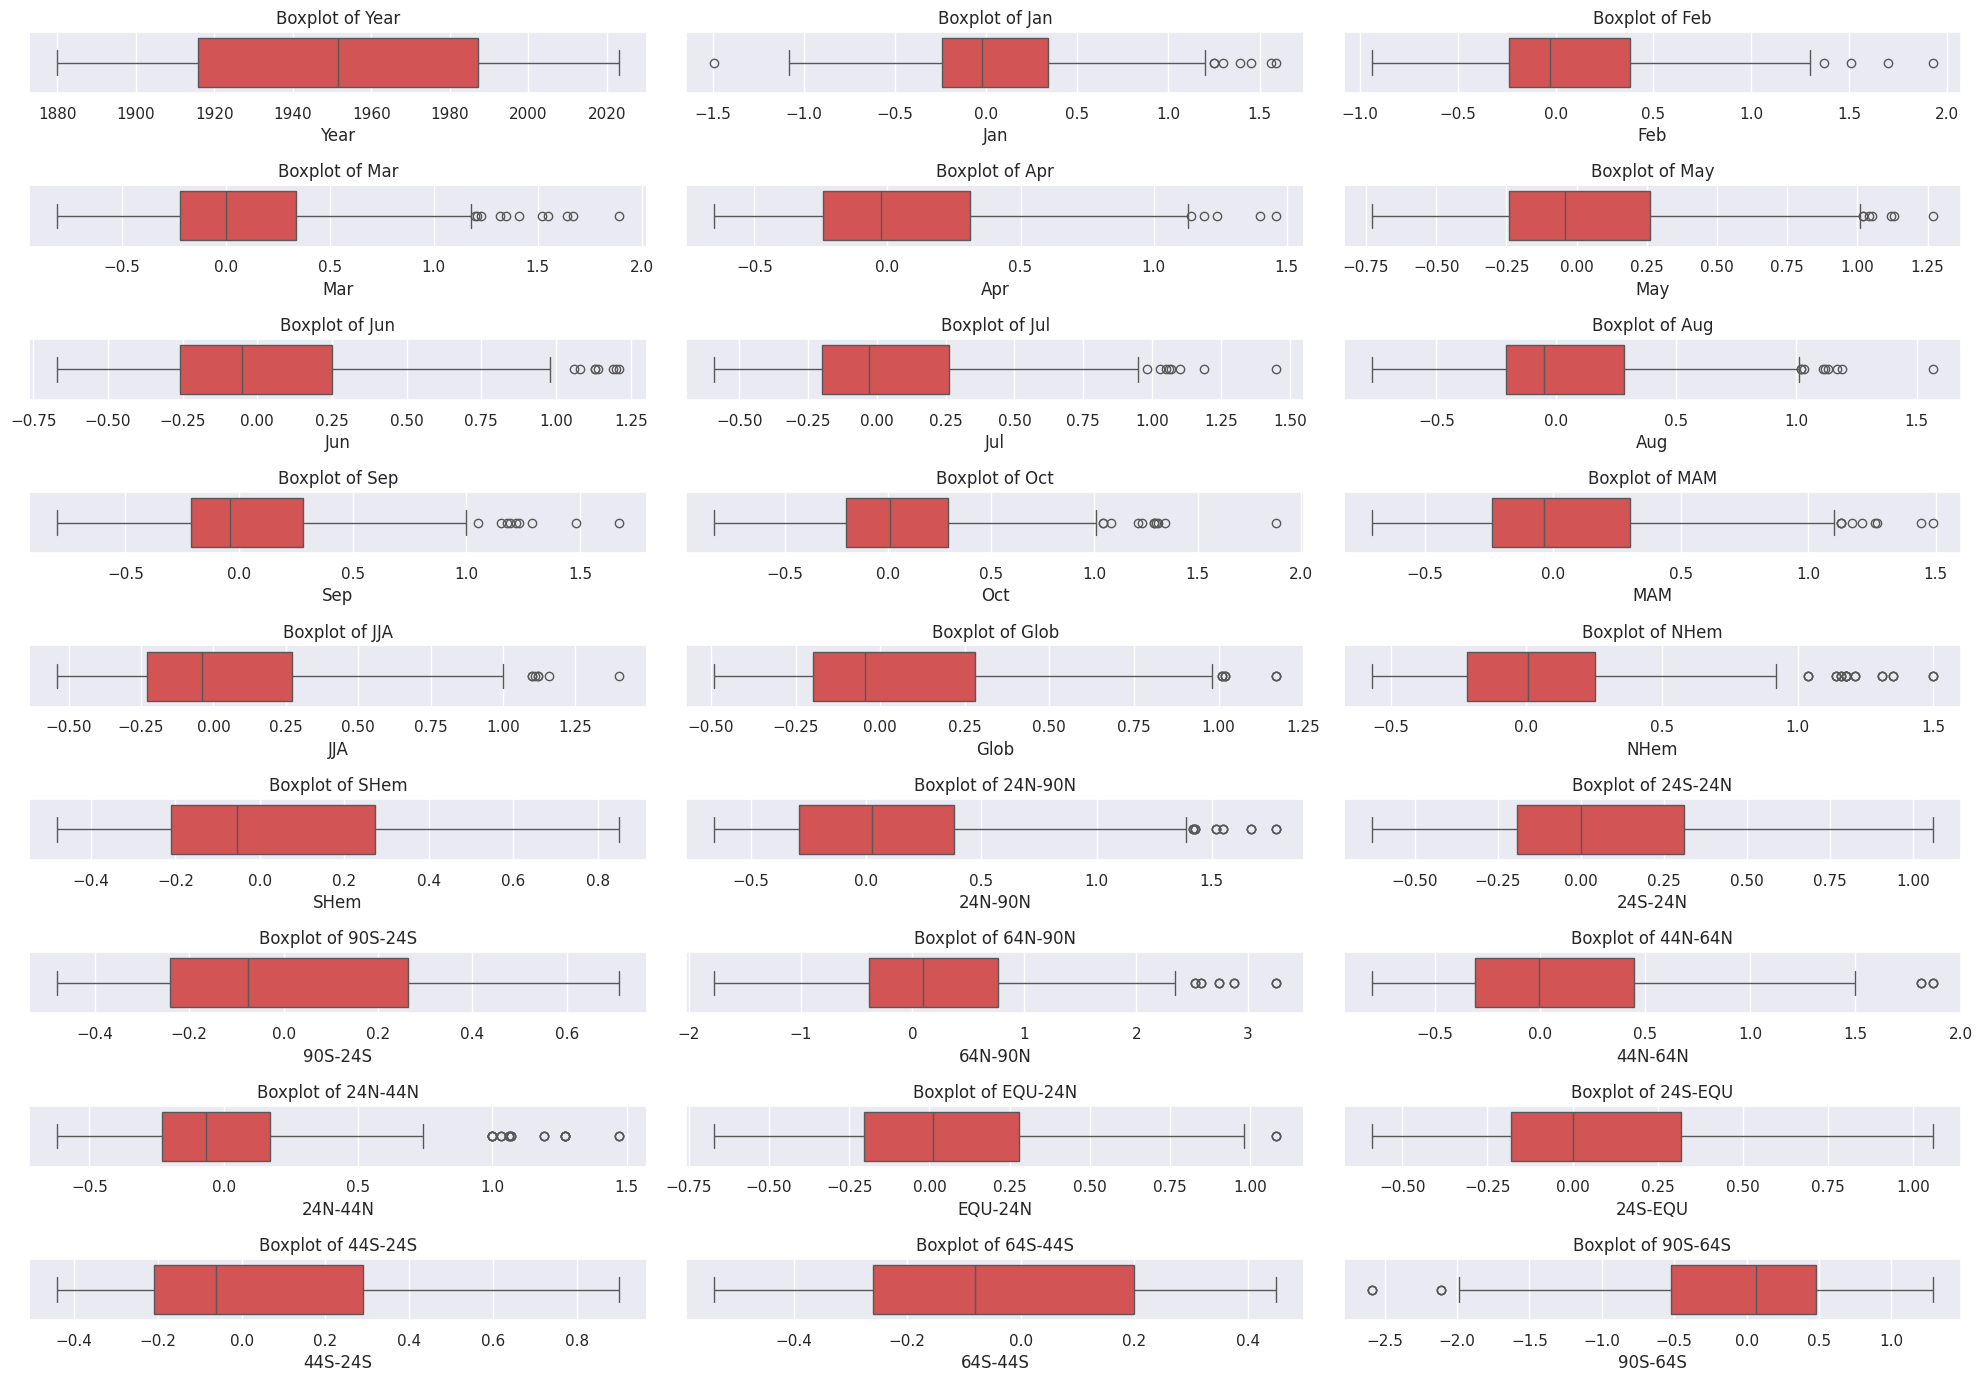

In [21]:
# Plotting boxplots for all numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_columns):
    plt.subplot(len(numerical_columns) // 3 + 1, 3, i + 1)
    sns.boxplot(x=Joined_data[col],
                color=sns.color_palette('rocket', as_cmap=True)(0.6))
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

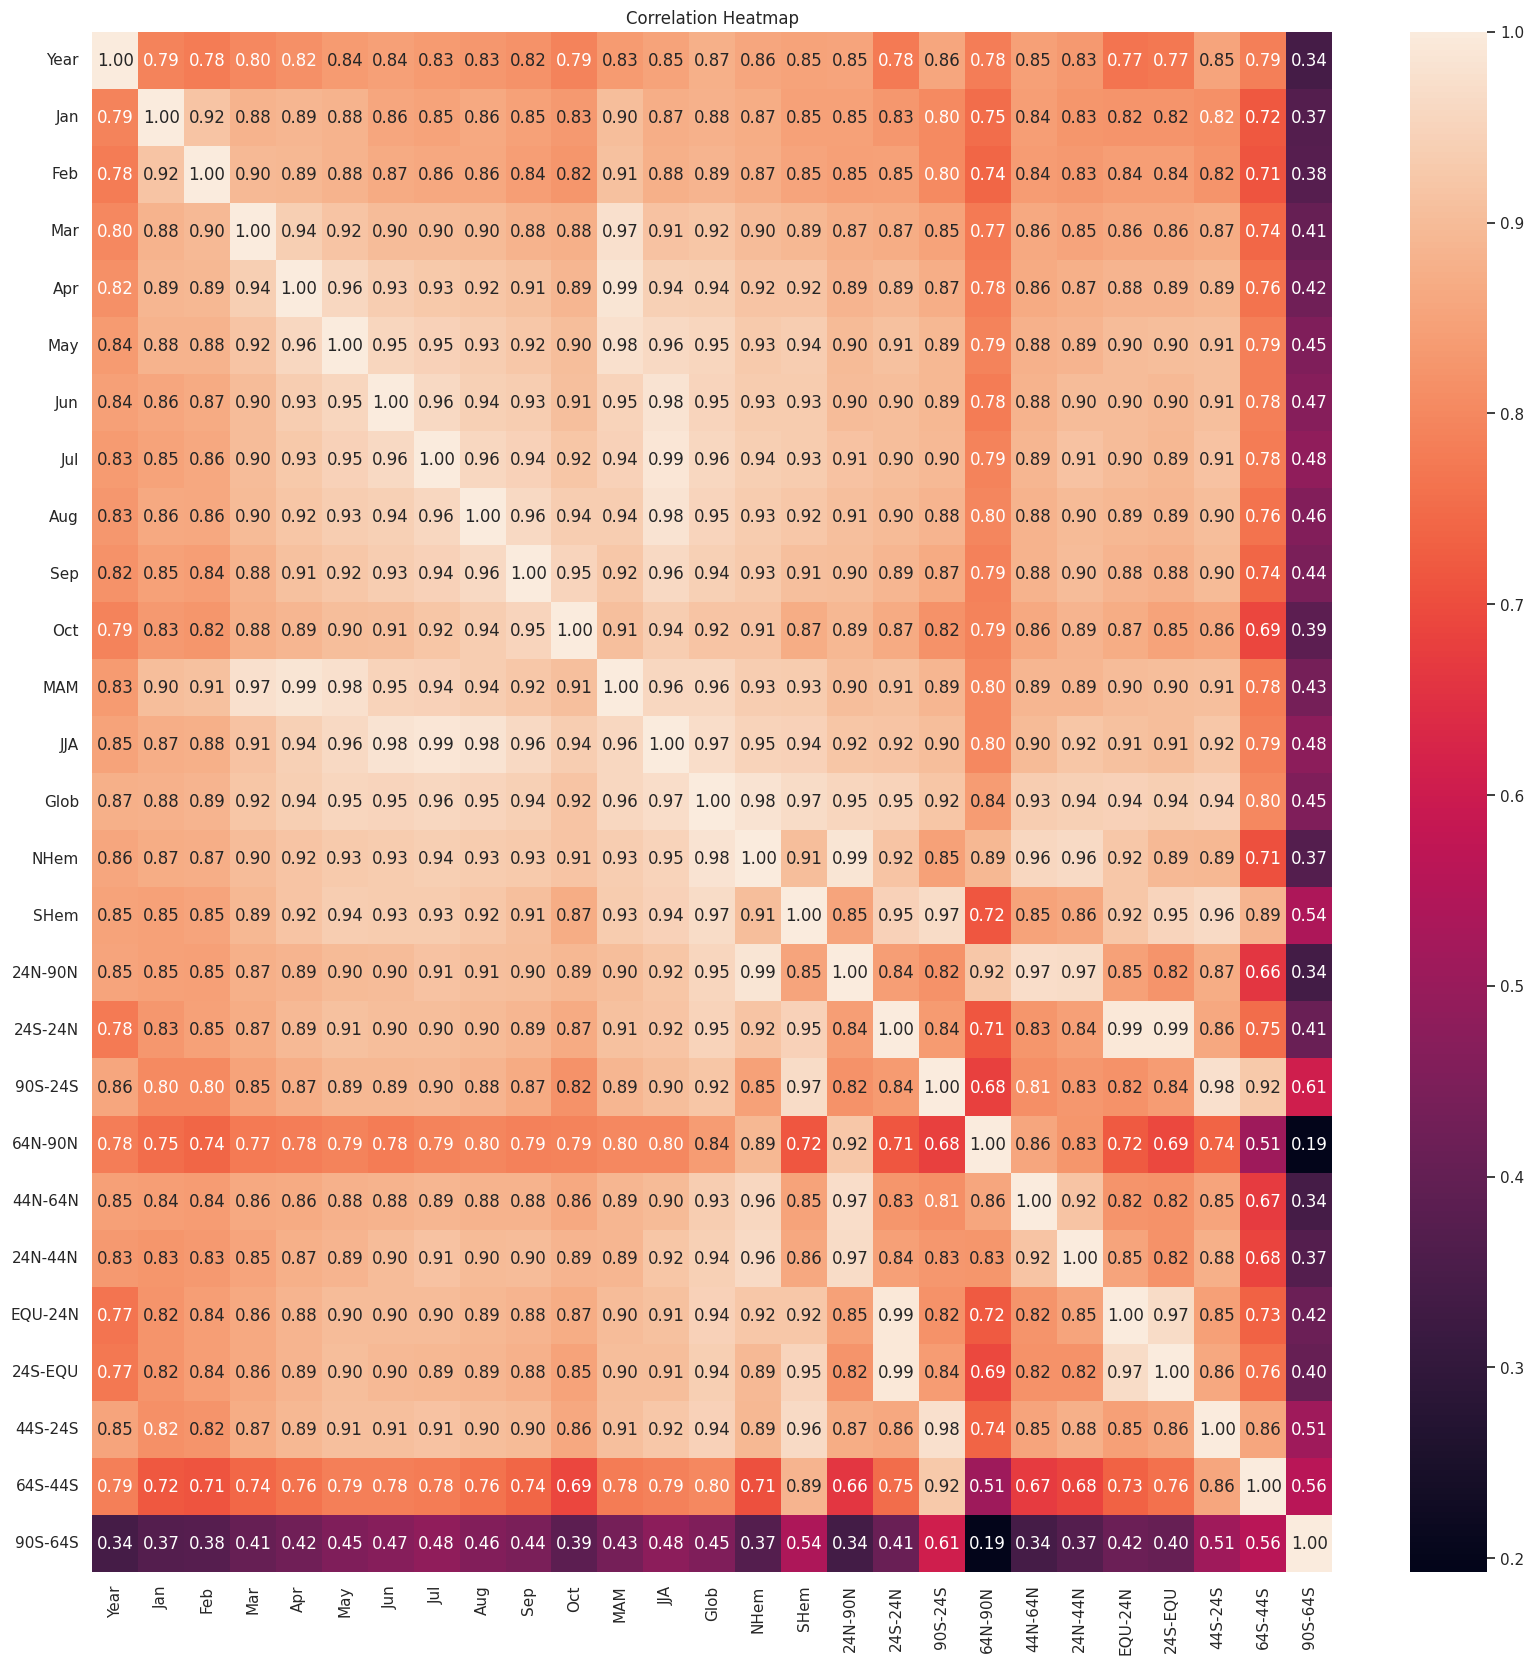

In [22]:
# Correlation heatmap for numerical features
plt.figure(figsize=(20, 20))
correlation_matrix = Joined_data[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

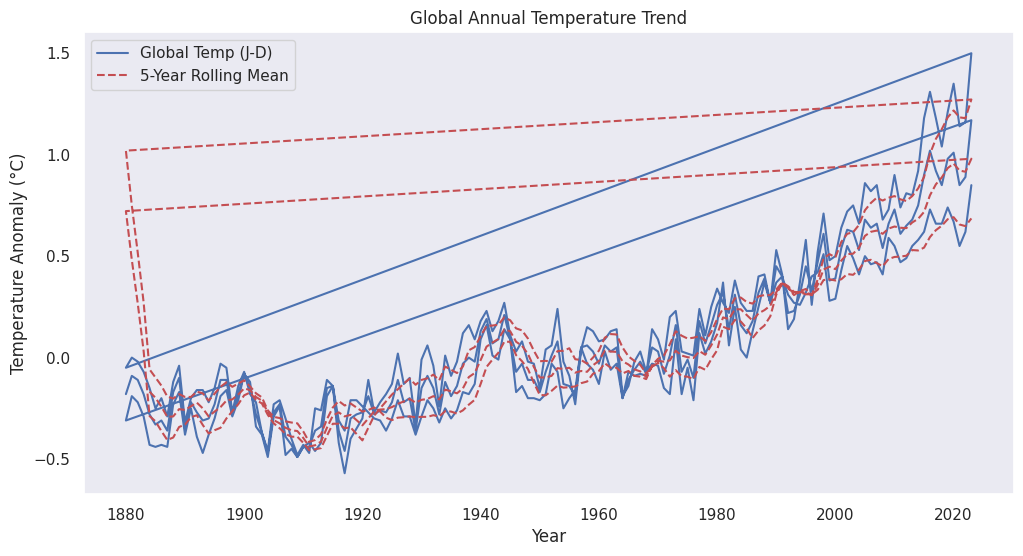

In [23]:
# Convert 'J-D' column to numeric, replacing non-numeric values with NaN
Joined_data['J-D'] = pd.to_numeric(Joined_data['J-D'], errors='coerce')


plt.figure(figsize=(12, 6))

# Plotting the trend for Global Temperature
plt.plot(Joined_data['Year'], Joined_data['J-D'], label='Global Temp (J-D)', color='b')

# Calculate rolling mean after converting to numeric
rolling_mean = Joined_data['J-D'].rolling(window=5).mean()
plt.plot(Joined_data['Year'], rolling_mean, label='5-Year Rolling Mean', color='r', linestyle='--')

plt.title('Global Annual Temperature Trend')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.grid()
plt.show()


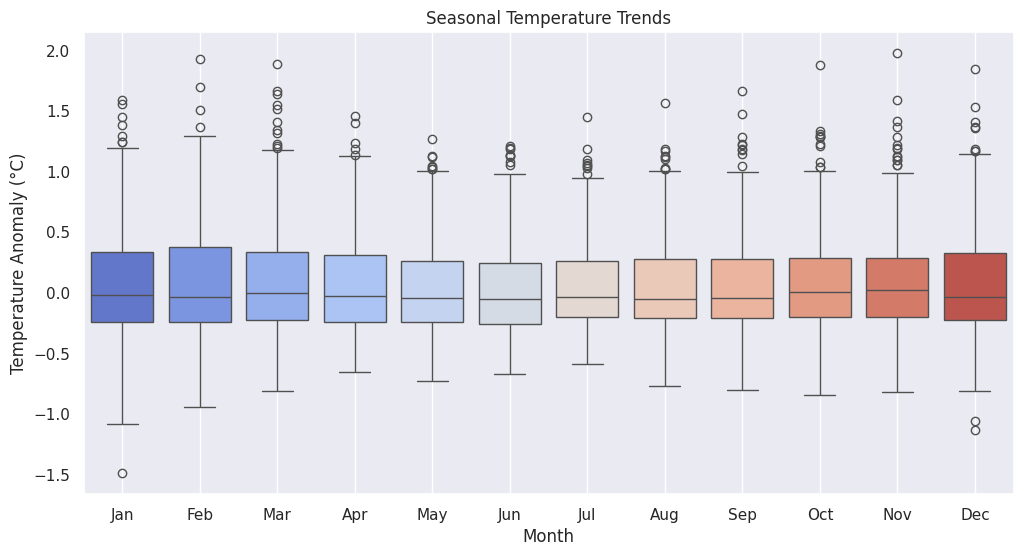

In [24]:
# Melt the dataframe to analyze monthly data
monthly_data = Joined_data.melt(id_vars=['Year'],
                                value_vars=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                                var_name='Month', value_name='Temperature')

# Convert Month names to numbers for sorting
monthly_data['Month'] = pd.Categorical(monthly_data['Month'],
                                       categories=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                                       ordered=True)

# Convert 'Temperature' column to numeric, replacing non-numeric values with NaN
monthly_data['Temperature'] = pd.to_numeric(monthly_data['Temperature'], errors='coerce')

# Drop rows with NaN values in 'Temperature'
monthly_data.dropna(subset=['Temperature'], inplace=True)

# Boxplot of monthly temperature anomalies
plt.figure(figsize=(12, 6))
sns.boxplot(data=monthly_data, x='Month', y='Temperature', palette='coolwarm')
plt.title('Seasonal Temperature Trends')
plt.ylabel('Temperature Anomaly (°C)')
plt.xlabel('Month')
plt.grid()
plt.show()

#PreProcessing

Encoding

In [25]:
df=Joined_data.copy()
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# Select columns using a list instead of a tuple
for col in ['Nov', 'Dec', 'J-D']:
    df[col] = label_encoder.fit_transform(df[col])


Scalling

In [26]:

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_columns.remove('Year')
numerical_features = numerical_columns  # List of numerical features
# Initialize the scaler
scaler = StandardScaler()
# Scale numerical features
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
# Display the first few rows of the scaled DataFrame
df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,...,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S
0,1880,-0.584377,-0.728816,-0.390698,-0.565827,-0.397813,-0.678077,-0.725679,-0.452085,-0.587396,...,-0.584839,-0.072647,-1.056352,-1.088817,-0.872235,-0.590605,-0.538223,-0.288169,0.366445,0.985439
1,1881,-0.584377,-0.507652,-0.148638,-0.054503,0.016047,-0.600246,-0.152715,-0.269805,-0.587396,...,0.067565,-0.232114,-1.173800,-1.039330,-0.638991,0.116001,0.048506,-0.318217,-0.066672,0.879964
2,1882,0.214940,0.133722,-0.104628,-0.541478,-0.501277,-0.704020,-0.616543,-0.373965,-0.561676,...,-0.329551,0.023034,-1.653379,-0.742412,-0.499045,-0.307962,-0.370586,-0.137929,0.330352,0.919517
3,1883,-0.784206,-0.972096,-0.456714,-0.590176,-0.604742,-0.288923,-0.370987,-0.530206,-0.741717,...,-0.669935,-0.072647,-0.429963,-1.187790,-0.755613,-0.675397,-0.677921,-0.288169,0.438631,0.761305
4,1884,-0.428954,-0.330721,-0.984844,-1.125848,-1.018601,-1.015344,-1.025803,-0.894767,-0.870318,...,-0.613205,-0.455370,-1.535931,-1.336249,-1.222101,-0.505812,-0.705860,-0.738890,0.113794,0.959070


Imputation

In [27]:
# Checking for missing values in the dataset
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Missing values in each column:")
print(missing_values[missing_values > 0])

df['D-N'] = pd.to_numeric(df['D-N'], errors='coerce')
df['DJF'] = pd.to_numeric(df['DJF'], errors='coerce')
# Imputing missing values
# Impute missing values in numerical columns using the median
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    median = df[col].median()
    df[col].fillna(median, inplace=True)

# Verify if there are still any missing values in numerical columns after imputation
print("Missing values after imputing numerical columns:")
print(df.isnull().sum().sort_values(ascending=False)[df.isnull().sum() > 0])


Missing values in each column:
D-N    3
DJF    3
dtype: int64
Missing values after imputing numerical columns:
Series([], dtype: int64)


In [28]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns.remove('Year')
# Apply PCA
n_components = 0.95  # Retain 95% of the variance
pca = PCA(n_components=n_components)
pca.fit(df[numerical_columns])
pca_df = pca.transform(df[numerical_columns])


# Convert the transformed data to a DataFrame
pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
pca_df = pd.DataFrame(pca_df, columns=pca_columns)

# Add the PCA components to the original DataFrame
df_pca = df.drop(columns=numerical_columns).reset_index(drop=True).join(pca_df)


# Display the first few rows of the PCA-transformed DataFrame
print("PCA-transformed DataFrame:")
df_pca.head()


PCA-transformed DataFrame:


,Year,SON,PC1,PC2,PC3,PC4,PC5,PC6
0,1880,-0.21,-3.093730,1.911028,-0.057435,-0.530342,0.129829,0.024266
1,1881,-0.19,-2.130902,1.620369,-0.771583,-0.909069,-0.726162,0.165858
2,1882,-0.19,-2.294492,1.858924,-0.547390,-0.837673,0.363551,0.424536
3,1883,-0.19,-3.067069,1.550669,0.330711,-0.469236,0.077576,-0.355396
4,1884,-0.28,-4.440112,1.960899,-0.393847,-0.000356,0.019357,0.488666


#Model

#lstm

In [29]:
# Target: Predict next year's annual temperature
df['Target'] = df['J-D'].shift(-1)  # Shift J-D for next year prediction

# Drop the last row as it has NaN in Target
df.dropna(subset=['Target'], inplace=True)

# Select features
features = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON', 'Glob',
       'NHem', 'SHem', '24N-90N', '24S-24N', '90S-24S', '64N-90N', '44N-64N',
       '24N-44N', 'EQU-24N', '24S-EQU', '44S-24S', '64S-44S', '90S-64S']
# Convert all columns in 'features' to numeric, handling errors
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())  # Fill NaN with median

X = df[features].values
y = df['Target'].values


In [30]:
# Create sequences for LSTM
sequence_length = 10  # Use 10 years of historical data
X_seq, y_seq = [], []
for i in range(len(X) - sequence_length):
    X_seq.append(X[i:i+sequence_length])
    y_seq.append(y[i+sequence_length])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)

In [31]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

In [32]:
# Define the LSTM model
model = Sequential()

# Add LSTM layers
model.add(LSTM(units=50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]),kernel_regularizer=regularizers.l2(0.01)))
model.add(Dropout(0.4))  # Dropout for regularization

# Second LSTM layer with L2 regularization and return_sequences=True to maintain 3D output
model.add(LSTM(units=50, activation='tanh', return_sequences=True, kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.4))

# Batch Normalization after the second LSTM layer
model.add(BatchNormalization())

# Third LSTM layer with L2 regularization and return_sequences=True
model.add(LSTM(units=50, activation='tanh', return_sequences=True, kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.4))

# Final LSTM layer to generate output, return_sequences=False
model.add(LSTM(units=50, activation='tanh', return_sequences=False))  # Final LSTM layer
model.add(Dropout(0.4))

# Add Dense layer for prediction
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 50)              │          16,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 10, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 10, 50)              │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 10, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,651 (303.32 KB)

 Trainable params: 77,551 (302.93 KB)

 Non-trainable params: 100 (400.00 B)

In [33]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Set global seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 1.7558 - val_loss: 1.5361
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5492 - val_loss: 1.4162
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.4474 - val_loss: 1.2750
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1816 - val_loss: 1.1470
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9122 - val_loss: 1.2654
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8886 - val_loss: 1.3063
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8363 - val_loss: 1.1268
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7313 - val_loss: 0.8988
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6110 - val_loss: 0.8687
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6120 - val_loss: 1.0377
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5934 - val_loss: 0.8472
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6

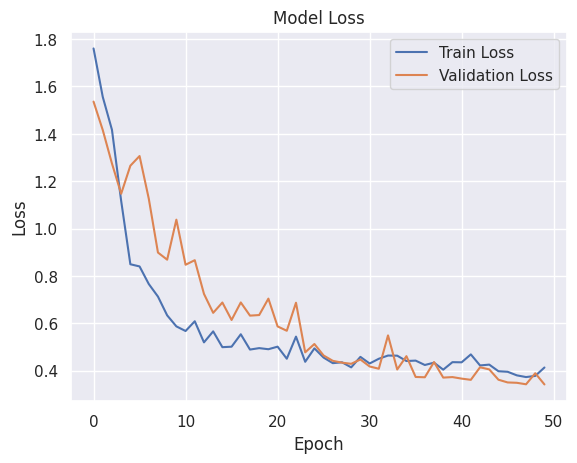

In [34]:
# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
# Evaluate model on test data
test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3376 
Test Loss: 0.3418992757797241


In [36]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step
Mean Absolute Error: 0.40008972271755333
R-squared: 0.7102101197144711


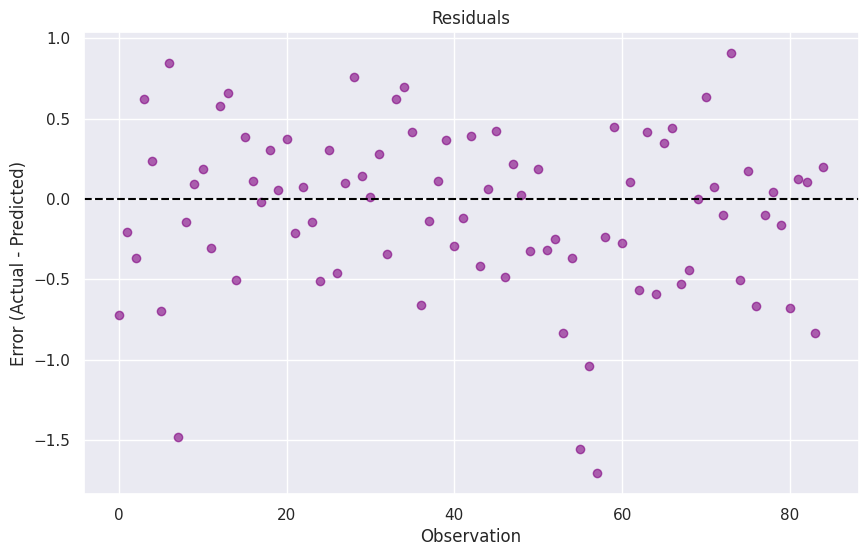

In [37]:
# Extract the first column of y_pred to match the shape of y_test
y_pred = y_pred.ravel()  # or y_pred = y_pred[:, 0] if it's a multi-column array

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, alpha=0.6, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals")
plt.xlabel("Observation")
plt.ylabel("Error (Actual - Predicted)")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


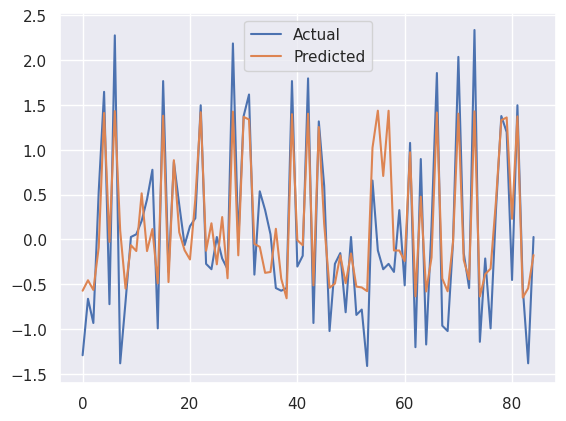

In [38]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Visualize predictions vs actual values
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()


#Prophet

In [40]:
from prophet import Prophet

# Prepare data for Prophet
prophet_data = df[['Year', 'J-D']].rename(columns={'Year': 'ds', 'J-D': 'y'})

# Convert 'Year' to datetime
prophet_data['ds'] = pd.to_datetime(prophet_data['ds'], format='%Y')

# Drop missing values
prophet_data.dropna(inplace=True)



In [41]:
# Initialize the Prophet model
model = Prophet(growth='linear',               # Set growth type: 'linear' or 'logistic'
    changepoint_prior_scale=0.05,  # Adjust flexibility for changepoints (default=0.05)
    seasonality_prior_scale=10,    # Regularization for seasonality (default=10)
    yearly_seasonality=True,       # Yearly seasonality (can be 'auto' or custom)
    weekly_seasonality=False,      # Weekly seasonality turned off
    daily_seasonality=False        # Daily seasonality turned off
)

# Add custom seasonality if needed (e.g., decadal patterns)
model.add_seasonality(name='decadal', period=10, fourier_order=5)


# Fit the model
model.fit(prophet_data)



DEBUG:cmdstanpy:input tempfile: /tmp/tmpxs_8h12v/_09pq1l0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxs_8h12v/klhrwotp.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1748', 'data', 'file=/tmp/tmpxs_8h12v/_09pq1l0.json', 'init=/tmp/tmpxs_8h12v/klhrwotp.json', 'output', 'file=/tmp/tmpxs_8h12v/prophet_modelmghtwnol/prophet_model-20241215214507.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:45:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:45:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


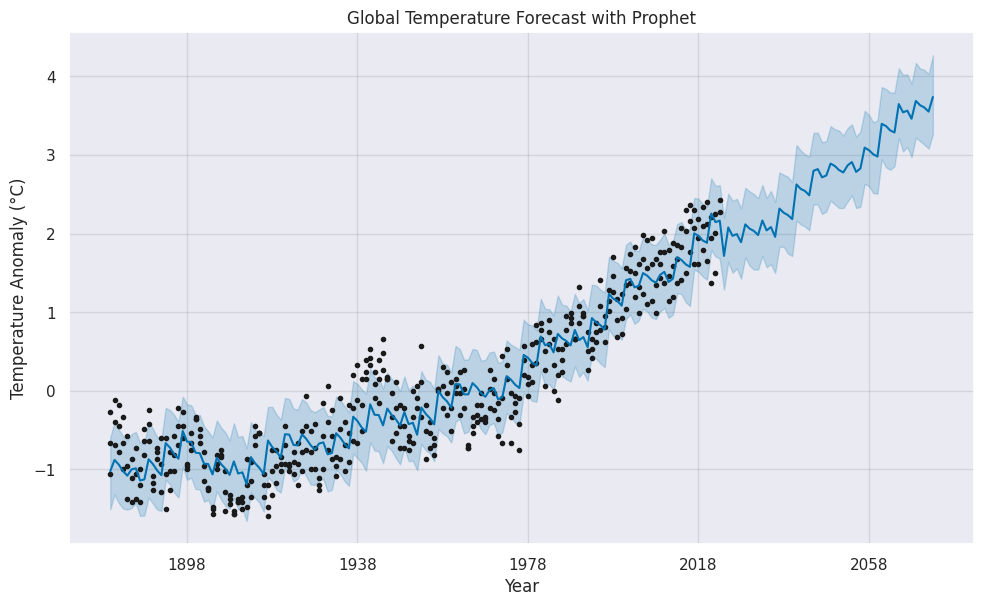

In [42]:
# Forecast the next 50 years
future = model.make_future_dataframe(periods=50, freq='Y')
forecast = model.predict(future)

# Visualize the forecast
fig1 = model.plot(forecast)
plt.title('Global Temperature Forecast with Prophet')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()




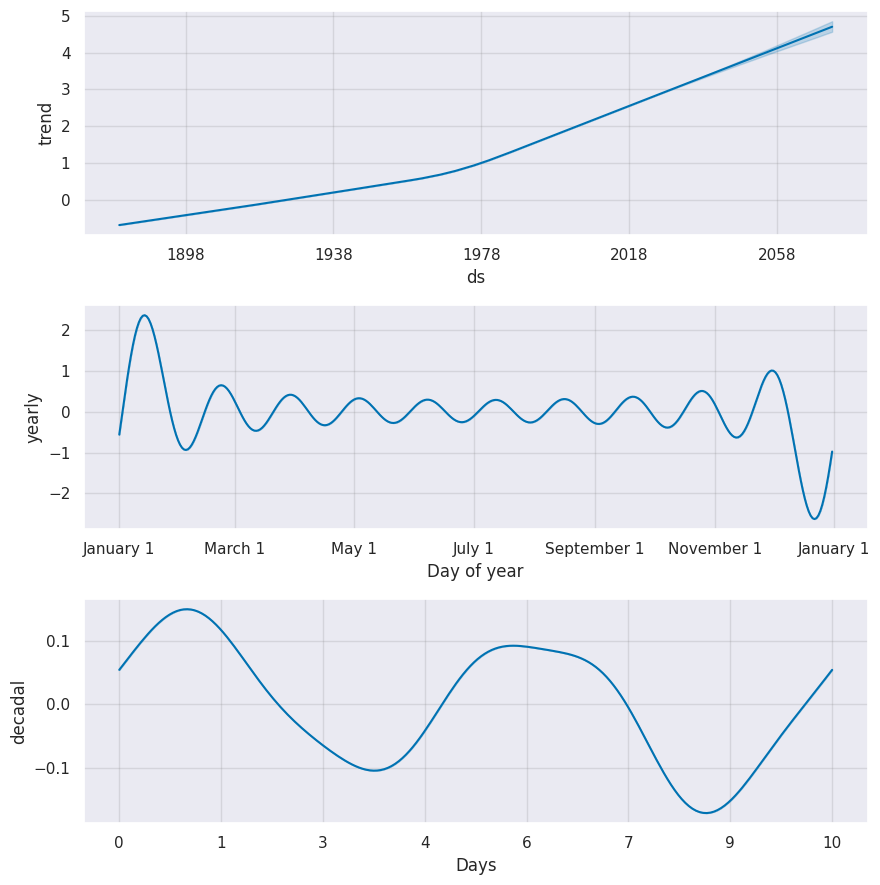

Forecasted Data:
            ds      yhat  yhat_lower  yhat_upper
189 2068-12-31  3.686262    3.219647    4.169591
190 2069-12-31  3.632394    3.175375    4.099006
191 2070-12-31  3.602774    3.129582    4.081368
192 2071-12-31  3.551035    3.080984    4.028266
193 2072-12-31  3.736013    3.263641    4.267037


In [43]:
# Plot the model components
fig2 = model.plot_components(forecast)
plt.show()

# Save forecast data for further analysis
forecast.to_csv("temperature_forecast.csv", index=False)

# Inspect forecast data
print("Forecasted Data:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())#forecast, and uncertinity interval

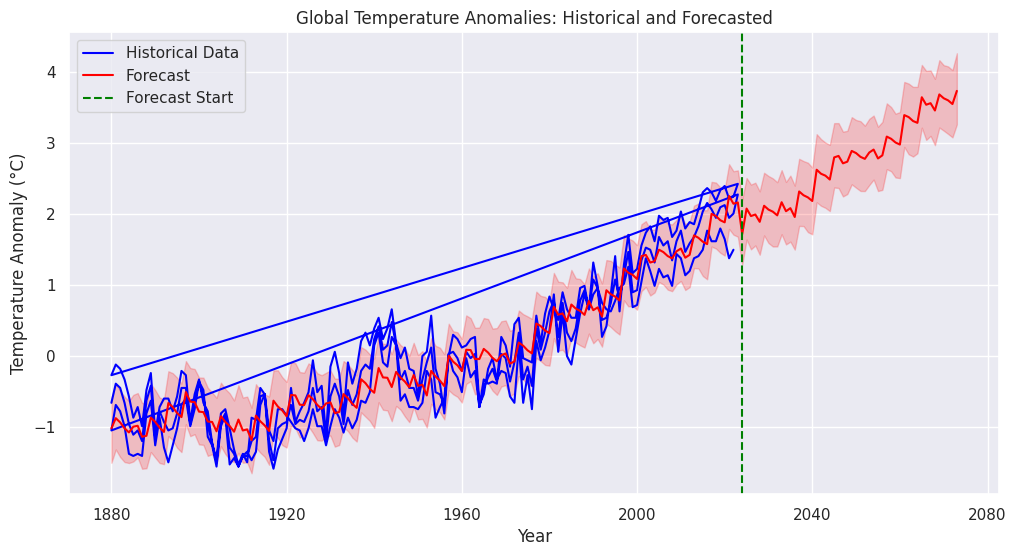

In [44]:
# Combine historical and forecasted data
full_data = pd.concat([prophet_data, forecast[['ds', 'yhat']]], ignore_index=True)

# Plot historical vs forecasted data
plt.figure(figsize=(12, 6))
plt.plot(prophet_data['ds'], prophet_data['y'], label='Historical Data', color='blue')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2)
plt.axvline(x=pd.to_datetime('2023-12-31'), color='green', linestyle='--', label='Forecast Start')
plt.title('Global Temperature Anomalies: Historical and Forecasted')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.show()


#Anomaly detection

Prophet-Based Anomaly Detection Implementation

Detected Anomalies:
            ds    actual      yhat  yhat_lower  yhat_upper  anomaly  \
1   1881-01-01 -0.392326 -0.878880   -1.320220   -0.398316     True   
2   1882-01-01 -0.452278 -0.938289   -1.427174   -0.493364     True   
8   1888-01-01 -0.632134 -1.127114   -1.585172   -0.682480     True   
29  1909-01-01 -1.561392 -0.898347   -1.367154   -0.412752     True   
37  1917-01-01 -1.471464 -0.631979   -1.097615   -0.205724     True   
..         ...       ...       ...         ...         ...      ...   
380 1972-01-01  0.447004 -0.078812   -0.526814    0.372331     True   
388 1980-01-01  0.836693  0.321379   -0.138221    0.766366     True   
407 1999-01-01  0.686813  1.141611    0.706654    1.626284     True   
429 2021-01-01  1.376262  2.253809    1.789838    2.702880     True   
430 2022-01-01  1.496167  2.145277    1.708746    2.603717     True   

       anomaly_type  
1    Above Expected  
2    Above Expected  
8    Above Expected  
29   Below Expected  
37   Below Expect

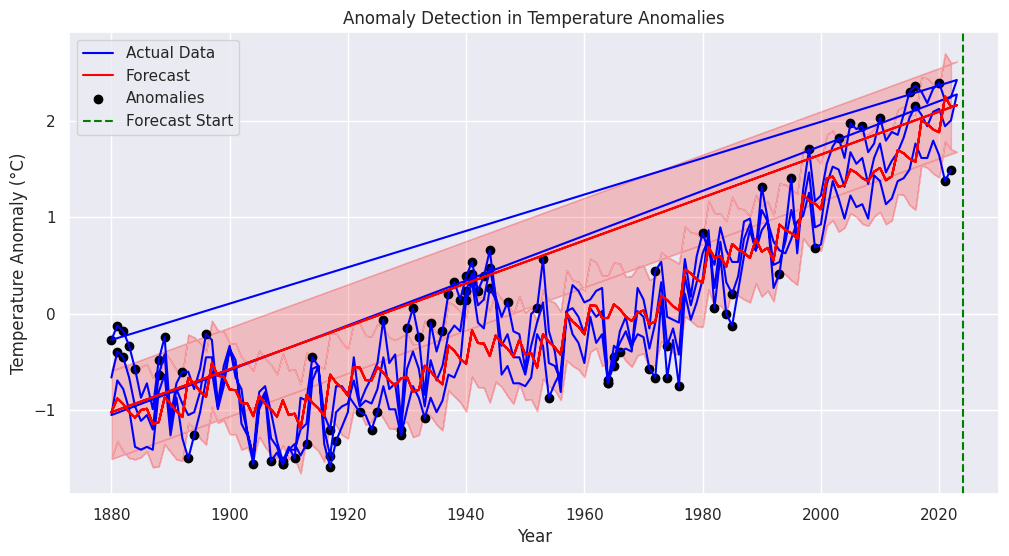

In [45]:
# Merge actual data with Prophet predictions
merged_data = pd.merge(
    prophet_data.rename(columns={'y': 'actual'}),
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='left'
)

# Define anomalies where actual values are outside the forecast bounds
merged_data['anomaly'] = ((merged_data['actual'] < merged_data['yhat_lower']) |
                          (merged_data['actual'] > merged_data['yhat_upper']))

# Add a flag for type of anomaly
merged_data['anomaly_type'] = merged_data.apply(
    lambda row: 'Above Expected' if row['actual'] > row['yhat_upper'] else (
        'Below Expected' if row['actual'] < row['yhat_lower'] else 'Normal'),
    axis=1
)

# Display anomalies
anomalies = merged_data[merged_data['anomaly'] == True]
print("Detected Anomalies:")
print(anomalies)

# Plot anomalies
plt.figure(figsize=(12, 6))
plt.plot(merged_data['ds'], merged_data['actual'], label='Actual Data', color='blue')
plt.plot(merged_data['ds'], merged_data['yhat'], label='Forecast', color='red')
plt.fill_between(merged_data['ds'], merged_data['yhat_lower'], merged_data['yhat_upper'], color='red', alpha=0.2)
plt.scatter(anomalies['ds'], anomalies['actual'], color='black', label='Anomalies')
plt.axvline(x=pd.to_datetime('2023-12-31'), color='green', linestyle='--', label='Forecast Start')
plt.title('Anomaly Detection in Temperature Anomalies')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.show()


Isolation Forest

In [46]:
from sklearn.ensemble import IsolationForest

# Select features for anomaly detection
features = ['yhat', 'yhat_upper', 'yhat_lower', 'actual']
iso_forest = IsolationForest(contamination=0.01)
merged_data['ml_anomaly'] = iso_forest.fit_predict(merged_data[features])


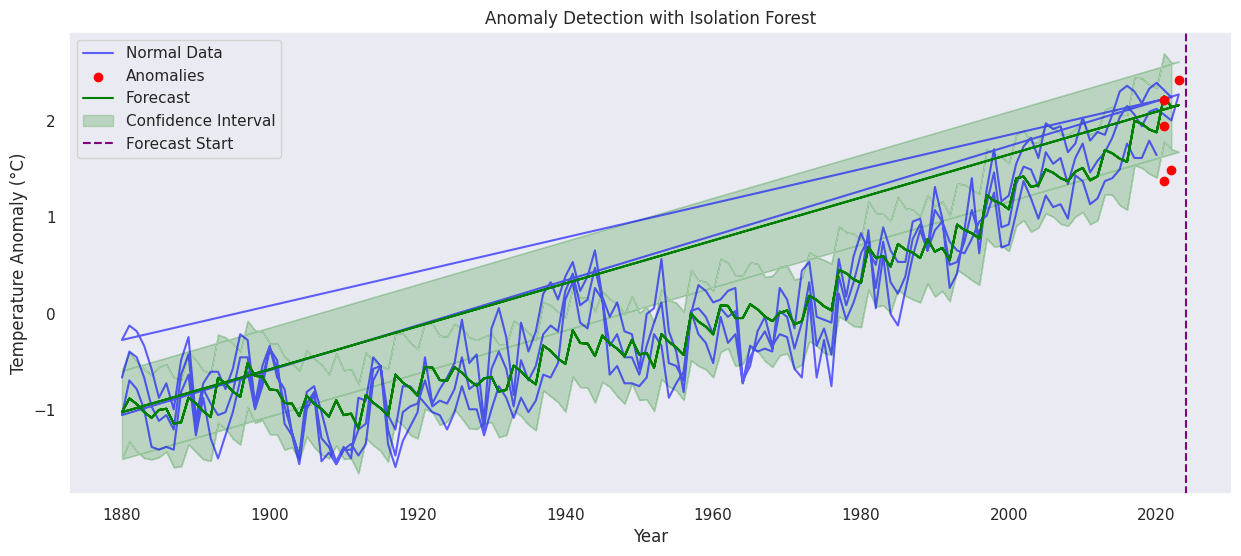

In [47]:
# Separate anomalies and normal points
anomalies = merged_data[merged_data['ml_anomaly'] == -1]
normal_points = merged_data[merged_data['ml_anomaly'] == 1]

# Plot the data
plt.figure(figsize=(15, 6))

# Plot normal points
plt.plot(normal_points['ds'], normal_points['actual'], label='Normal Data', color='blue', alpha=0.6)

# Plot detected anomalies
plt.scatter(anomalies['ds'], anomalies['actual'], color='red', label='Anomalies', zorder=5)

# Plot the forecasted values
plt.plot(merged_data['ds'], merged_data['yhat'], label='Forecast', color='green')

# Highlight the forecasted confidence intervals
plt.fill_between(merged_data['ds'], merged_data['yhat_lower'], merged_data['yhat_upper'],
                 color='green', alpha=0.2, label='Confidence Interval')

# Add labels and title
plt.axvline(x=pd.to_datetime('2023-12-31'), color='purple', linestyle='--', label='Forecast Start')
plt.title('Anomaly Detection with Isolation Forest')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.grid()
plt.show()


#Alert System

In [48]:
!pip install python-dotenv
import os
import smtplib
from email.message import EmailMessage
from email.utils import formataddr
from pathlib import Path

Detected Future Anomalies:
            ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
146 2025-12-31  2.861929    1.501830    2.415334     2.860854     2.863474   
147 2026-12-31  2.901148    1.556678    2.441754     2.899059     2.903726   
148 2027-12-31  2.940368    1.425584    2.319762     2.937136     2.944137   
151 2030-12-31  3.058135    1.541732    2.502629     3.050762     3.066176   
152 2031-12-31  3.097354    1.542804    2.449024     3.087795     3.106931   
153 2032-12-31  3.136682    1.714691    2.619305     3.125519     3.148010   
155 2034-12-31  3.215121    1.610599    2.541724     3.199609     3.229840   
158 2037-12-31  3.332888    1.830192    2.746842     3.311764     3.354741   
159 2038-12-31  3.372107    1.744690    2.723092     3.348693     3.396263   
160 2039-12-31  3.411327    1.713819    2.655389     3.385728     3.437670   
162 2041-12-31  3.489874    2.115710    3.055991     3.459223     3.521856   
163 2042-12-31  3.529094    2.087235 

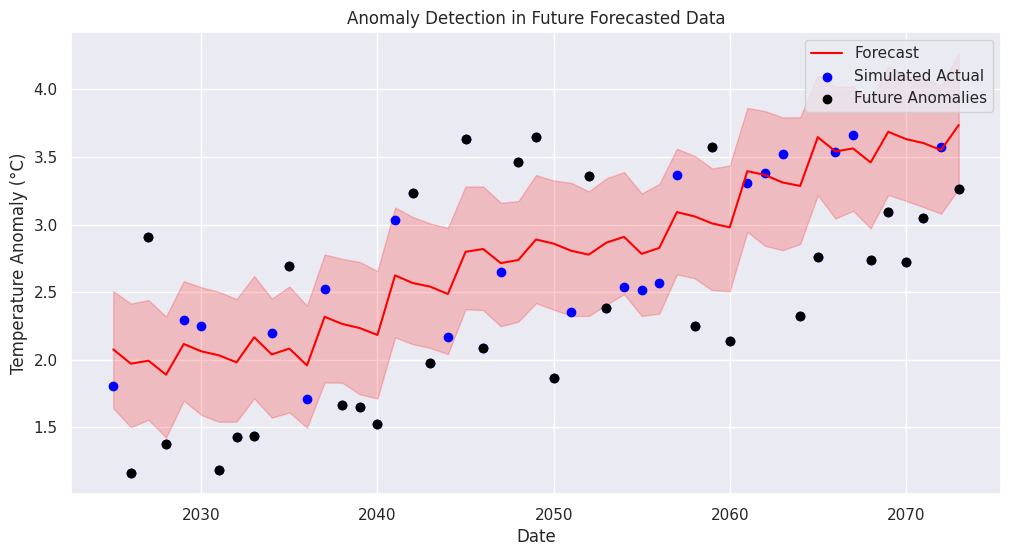

In [55]:
# Filter only future dates in the forecast
future_forecast = forecast[forecast['ds'] > '2024-01-01']  # Adjust based on the actual current date

# Simulated future "actual" values
future_forecast['future_actual'] = future_forecast['yhat'] + np.random.uniform(-1, 1, size=len(future_forecast))

# Define anomalies where future actuals are outside forecast bounds
future_forecast['anomaly'] = ((future_forecast['future_actual'] < future_forecast['yhat_lower']) |
                              (future_forecast['future_actual'] > future_forecast['yhat_upper']))

# Add a flag for type of anomaly
future_forecast['anomaly_type'] = future_forecast.apply(
    lambda row: 'Above Expected' if row['future_actual'] > row['yhat_upper'] else (
        'Below Expected' if row['future_actual'] < row['yhat_lower'] else 'Normal'),
    axis=1
)

# Display anomalies in future forecast
future_anomalies = future_forecast[future_forecast['anomaly'] == True]
print("Detected Future Anomalies:")
print(future_anomalies)

# Send email alerts for anomalies
for _, row in future_anomalies.iterrows():
    subject = "Future Anomaly Detected in Forecast"
    body = (f"An anomaly was detected for forecasted date {row['ds']}:\n"
            f"Forecasted Value: {row['yhat']}\n"
            f"Actual (Simulated): {row['future_actual']}\n"
            f"Expected Range: [{row['yhat_lower']}, {row['yhat_upper']}]\n"
            f"Type: {row['anomaly_type']}")
    to = "meenakshi.rajesh95@gmail.com"
    email_alert(subject, body, to)

# Plot anomalies in forecasted data (only future)
plt.figure(figsize=(12, 6))
plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Forecast', color='red')
plt.fill_between(future_forecast['ds'], future_forecast['yhat_lower'], future_forecast['yhat_upper'], color='red', alpha=0.2)
plt.scatter(future_forecast['ds'], future_forecast['future_actual'], label='Simulated Actual', color='blue')
plt.scatter(future_anomalies['ds'], future_anomalies['future_actual'], color='black', label='Future Anomalies')
plt.title('Anomaly Detection in Future Forecasted Data')
plt.xlabel('Date')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.show()
